In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np

from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.MisRegistration import MisRegistration
from OOPAO.Pyramid import Pyramid
from OOPAO.ShackHartmann import ShackHartmann
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.calibration.ao_calibration import ao_calibration
from OOPAO.calibration.compute_KL_modal_basis import compute_M2C
from OOPAO.tools.displayTools import displayMap




     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


ImportError: cannot import name 'set_binning' from 'OOPAO.tools.tools' (/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/OOPAO/tools/tools.py)

In [2]:
# 创建望远镜
tel = Telescope(resolution          = 120, # 分辨率
                diameter            = 8, # 直径
                samplingTime        = 1/1000, # 采样时间
                centralObstruction  = 0) # 中心遮挡比例

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope


In [3]:
# 创建自然引导星
ngs=Source(optBand   = 'I', # 光波段
           magnitude = 8) # 星等，表示光源的亮度
ngs*tel

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       8.0    4629306.6 
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
    Source NGS          790.0              [nm]       
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
NGS(I) ~~> telescope


Creation of layer1/5 ...
-> Computing the initial phase screen...
initial phase screen : 0.022350549697875977 s
ZZt.. : 2.2602453231811523 s
ZXt.. : 1.1870110034942627 s
XXt.. : 0.5365631580352783 s
Done!
Creation of layer2/5 ...
-> Computing the initial phase screen...
initial phase screen : 0.02515864372253418 s
ZZt.. : 0.0 s
ZXt.. : 0.0 s
XXt.. : 0.0 s
SCAO system considered: covariance matrices were already computed!
Done!
Creation of layer3/5 ...
-> Computing the initial phase screen...
initial phase screen : 0.029996156692504883 s
ZZt.. : 0.0 s
ZXt.. : 0.0 s
XXt.. : 0.0 s
SCAO system considered: covariance matrices were already computed!
Done!
Creation of layer4/5 ...
-> Computing the initial phase screen...
initial phase screen : 0.03658580780029297 s
ZZt.. : 0.0 s
ZXt.. : 0.0 s
XXt.. : 0.0 s
SCAO system considered: covariance matrices were already computed!
Done!
Creation of layer5/5 ...
-> Computing the initial phase screen...
initial phase screen : 0.03454113006591797 s
ZZt..

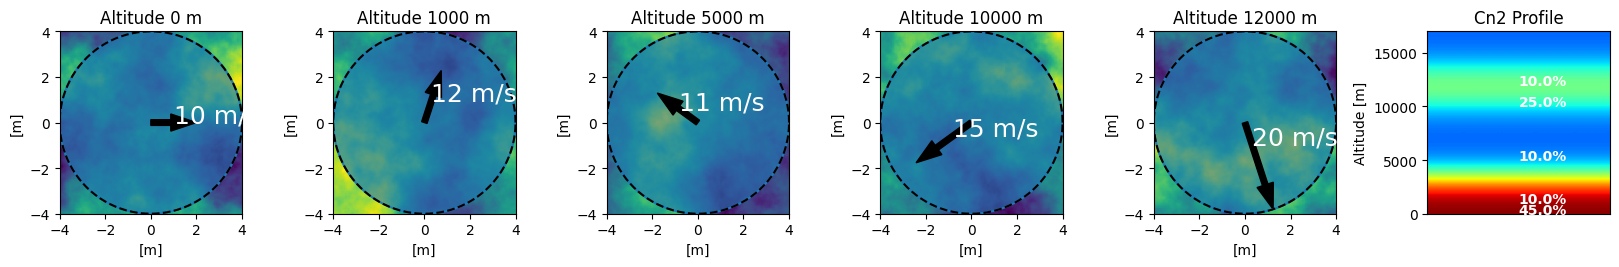

In [4]:
atm=Atmosphere(telescope     = tel,
               r0            = 0.15, # 大气湍流的弗里德参数（Fried parameter），表示大气相干长度，单位为米
               L0            = 30, # 大气湍流的外尺度（Outer scale），单位为米
               windSpeed     = [10,12,11,15,20] , # 每个湍流层的风速，单位为米/秒
               fractionalR0  = [0.45,0.1,0.1,0.25,0.1], # 每个湍流层的 Cn² 剖面，表示每个层对总湍流的贡献比例
               windDirection = [0,72,144,216,288], # 每个湍流层的风向，单位为度
               altitude      = [0, 1000,5000,10000,12000 ]) # 每个湍流层的海拔高度，单位为米
atm.initializeAtmosphere(telescope=tel) # 初始化
atm.display_atm_layers() # 可视化//第一个可以修改的参数，大气环境我们要怎么检测得到

In [5]:
atm.print_properties()

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% ATMOSPHERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%
   Layer     Direction     Speed      Altitude      Cn2     
               [deg]       [m/s]        [m]       [m-2/3]   
----------------------------------------------------------------------
     1           0           10          0          0.45    
------------------------------------------------------------------
     2           72          12         1000        0.1     
------------------------------------------------------------------
     3          144          11         5000        0.1     
------------------------------------------------------------------
     4          216          15        10000        0.25    
------------------------------------------------------------------
     5          288          20        12000        0.1     
------------------------------------------------------------------
    r0 @500 nm         0.15 [m]     
        L0              30 [m]      
  Seeing @500nm       

In [6]:
print(tel.isPaired)
tel+atm # 望远镜与大气结合
print(tel.isPaired)

False
Telescope and Atmosphere combined!
True


In [7]:
# 创建变形镜
dm=DeformableMirror(telescope    = tel,
                    nSubap       = 20, # 沿望远镜直径的变形镜驱动器数，即总驱动数=nSubap*nSubap
                    mechCoupling = 0.45) # 驱动器之间的机械耦合系数,用于描述变形镜的各个驱动器之间的机械相互作用程度

No coordinates loaded.. taking the cartesian geometry as a default
Generating a Deformable Mirror: 
Computing the 2D zonal modes...
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DEFORMABLE MIRROR %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Controlled Actuators        357        
         M4                False       
        Pitch               0.4               [m]        
 Mechanical Coupling        0.45              [%]        
-------------------------------------------------------------------------------
Mis-registration:
Rotation [deg]	Shift X [m]	Shift Y [m]	Radial Scaling [%]	Tangential Scaling [%]
      0       	     0     	     0     	        0         	          0           
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [8]:
# 创建SH-WFS 

wfs = ShackHartmann(nSubap              = 20, #  沿望远镜直径的子孔径数
                    telescope           = tel,
                    lightRatio          = 0.3, # 用于筛选有效子孔径
                    is_geometric        = False, # 是否启用几何模式（直接测量梯度）
                    threshold_cog       = 0.01) # 计算光斑质心时的阈值
gainCL                  = 0.6  # 传感增益

Selecting valid subapertures based on flux considerations..
Acquiring reference slopes..
Done!
Setting slopes units..
Done!
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SHACK HARTMANN WFS %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    Subapertures            20        
  Subaperture Size         0.4               [m]        
     Pixel FoV             0.41            [arcsec]     
   Subapertue FoV          2.44            [arcsec]     
 Valid Subaperture         332        
   Binning Factor           1         
   Geometric WFS          False       
  Shannon Sampling        False       
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [9]:
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()

'''
加载或生成模态基,即模式到控制矩阵（M2C）用于将模式映射到变形镜（DM）的控制信号
计算或加载交互矩阵
'''
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_332_subap_diffractive...
Done!
No Modal Gains found. All gains set to 1


In [10]:
ao_calib.M2C.shape

(357, 357)

In [ ]:
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 20
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 传感增益
wfs.cam.photonNoise     = True
display                 = True

for i in range(param['nLoop']):
    a=time.time()
    # 更新所有湍流层的相位屏，模拟时间演化
    atm.update()
    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
       
    tel*dm*wfs
    
    '''
    更新DM的控制信号
    dm.coefs：变形镜的控制系数，表示每个驱动器的位移量。 11111
    
    gainCL：闭环控制增益，用于调节校正的强度    11111
    波前传感器的增益,而采样频率通常是和望远镜的采样频率同步的
    
    M2C_CL：模式到控制矩阵，用于将模式映射到变形镜的控制信号。
    calib_CL.M：交互矩阵的伪逆矩阵，用于将波前传感器的信号转换为模式系数。
    wfsSignal:shwfs测量的斜率，形状：（2*nValidSubaperture,）
    ''' 
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal
    
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')
    
    #实际代码的SR比不通过图像的比来得到，而使用近似的相位差来得到，
    #后续需要修改 改成用科学成像相机的方式来测量斯特列尔比
    SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')


Telescope and Atmosphere combined!
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
WARNING !!!! THE LIGHT IN THE SUBAPERTURE IS MAYBE WRAPPING !!!18.1 % of the total flux detected on the edges of the subapertures. You may want to increase the seeing value or the resolution
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Elapsed time: 0.050626277923583984 s
Loop0/20 Turbulence: 729.9637422512043 -- Residual:729.9637422512043

Elapsed time: 0.05801248550415039 s
Loop1/20 Turbulence: 729.8126483109866 -- Residual:729.8126483109866

Elapsed time: 0.05566287040710449 s
Loop2/20 Turbulence: 729.6557139892027 -- Residual:363.555241948494

Elapsed time: 0.0625603199005127 s
Loop3/20 Turbulence: 729.4836773687359 -- Residual:110.82261250464865

Elapsed time: 0.0760200023651123 s
Loop4/20 Turbulence: 729.3034888380988 -- Residual:24

Text(0, 0.5, 'WFE [nm]')

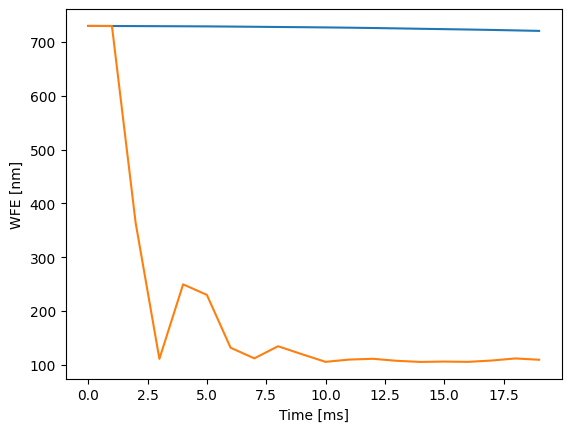

In [21]:
# 波前误差
plt.figure()
plt.plot(total)
plt.plot(residual)
plt.xlabel('Time [ms]')
plt.ylabel('WFE [nm]')


Text(0, 0.5, 'SR')

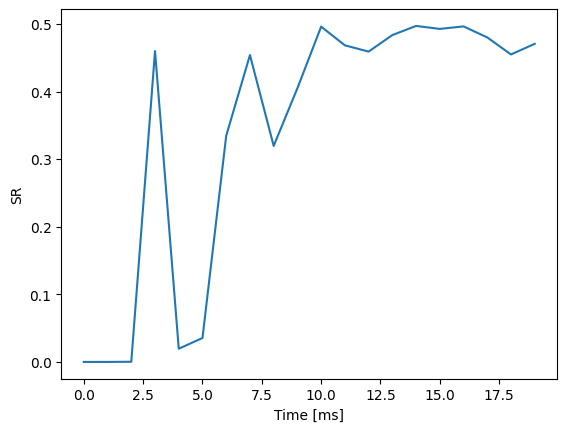

In [22]:
plt.plot(SR)
plt.xlabel('Time [ms]')
plt.ylabel('SR')

Telescope and Atmosphere combined!


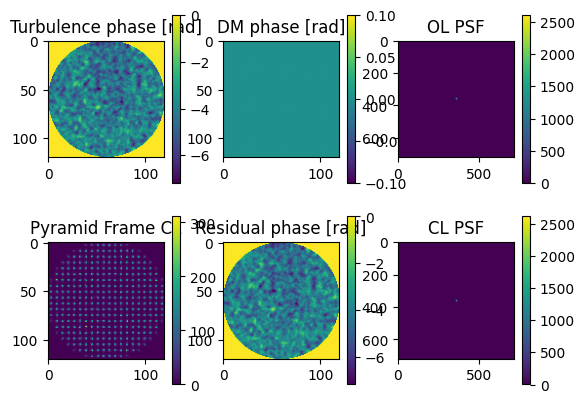

(357,) (357, 664) (664,)
332
Elapsed time: 0.23368620872497559 s
Loop0/20 Turbulence: 685.7846351407039 -- Residual:685.7846351407039
(357,) (357, 664) (664,)
332
Elapsed time: 0.2283470630645752 s
Loop1/20 Turbulence: 687.0947527759645 -- Residual:687.0947527759645
(357,) (357, 664) (664,)
332
Elapsed time: 0.2478940486907959 s
Loop2/20 Turbulence: 688.447370988424 -- Residual:337.3616246882235
(357,) (357, 664) (664,)
332
Elapsed time: 0.360992431640625 s
Loop3/20 Turbulence: 689.8224803155009 -- Residual:110.16042854566855
(357,) (357, 664) (664,)
332
Elapsed time: 0.20490574836730957 s
Loop4/20 Turbulence: 691.2484692630447 -- Residual:237.13462971628087
(357,) (357, 664) (664,)
332
Elapsed time: 0.21822190284729004 s
Loop5/20 Turbulence: 692.6847923055041 -- Residual:212.56641923030472
(357,) (357, 664) (664,)
332
Elapsed time: 0.2492222785949707 s
Loop6/20 Turbulence: 694.1165288939739 -- Residual:122.35959131612462
(357,) (357, 664) (664,)
332
Elapsed time: 0.23285150527954102 s

In [14]:
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0

im_atm_list = []
im_dm_list = []
im_PSF_OL_list = []
im_wfs_CL_list = []
im_residual_list = []
im_PSF_list = []
plt.ion()
# setup the display
fig         = plt.figure(79)
ax1         = plt.subplot(2,3,1)
im_atm      = ax1.imshow(tel.src.phase)
plt.colorbar(im_atm)
plt.title('Turbulence phase [rad]')


ax2         = plt.subplot(2,3,2)
im_dm       = ax2.imshow(dm.OPD*tel.pupil)
plt.colorbar(im_dm)
plt.title('DM phase [rad]')
tel.computePSF(zeroPaddingFactor=6)

ax4         = plt.subplot(2,3,3)
im_PSF_OL   = ax4.imshow(tel.PSF)
plt.colorbar(im_PSF_OL)
plt.title('OL PSF')


ax3         = plt.subplot(2,3,5)
im_residual = ax3.imshow(tel.src.phase)
plt.colorbar(im_residual)
plt.title('Residual phase [rad]')

ax5         = plt.subplot(2,3,4)
im_wfs_CL   = ax5.imshow(wfs.cam.frame)
plt.colorbar(im_wfs_CL)
plt.title('Pyramid Frame CL')

ax6         = plt.subplot(2,3,6)
im_PSF      = ax6.imshow(tel.PSF)
plt.colorbar(im_PSF)
plt.title('CL PSF')

plt.show()

param['nLoop'] = 20
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 增益
wfs.cam.photonNoise     = True
display                 = True

for i in range(param['nLoop']):
    a=time.time()
    # 更新所有湍流层的相位屏，模拟时间演化
    atm.update()
    # 记录总的波前误差
    # tel.pupil>0表示能够接收到光的位置
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
     # save turbulent phase
    turbPhase = tel.src.phase
    if display == True:
        # compute the OL PSF and update the display
        tel.computePSF(zeroPaddingFactor=6)
        im_PSF_OL_list.append(np.log(tel.PSF/tel.PSF.max()))

     # propagate to the WFS with the CL commands applied
    tel*dm*wfs

     # save the DM OPD shape
    dmOPD=tel.pupil*dm.OPD*2*np.pi/ngs.wavelength



    '''
    更新DM的控制信号
    dm.coefs：变形镜的控制系数，表示每个驱动器的位移量。
    gainCL：闭环控制增益，用于调节校正的强度
    M2C_CL：模式到控制矩阵，用于将模式映射到变形镜的控制信号。
    calib_CL.M：交互矩阵的伪逆矩阵，用于将波前传感器的信号转换为模式系数。
    wfsSignal:shwfs测量的斜率，形状：（2*nValidSubaperture,）
    ''' 
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    print(dm.coefs.shape,calib_CL.M.shape, wfsSignal.shape)
    print(wfs.nValidSubaperture)


     # store the slopes after computing the commands => 2 frames delay
    wfsSignal=wfs.signal
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')
    # update displays if required
    if display==True:

       # Turbulence
       im_atm_list.append(turbPhase)
       # WFS frame
       C=wfs.cam.frame
       im_wfs_CL_list.append(C)
       # DM OPD
       im_dm_list.append(dmOPD)

       # residual phase
       D=tel.src.phase
       D=D-np.mean(D[tel.pupil])
       im_residual_list.append(D)

       tel.computePSF(zeroPaddingFactor=6)
       im_PSF_list.append(np.log(tel.PSF/tel.PSF.max()))


    SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    OPD=tel.OPD[np.where(tel.pupil>0)]

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')


loop 5


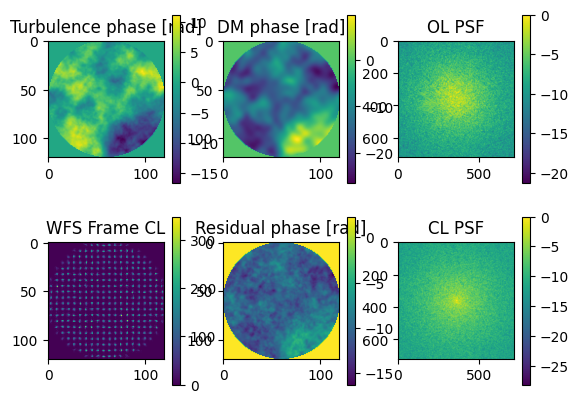

loop 10


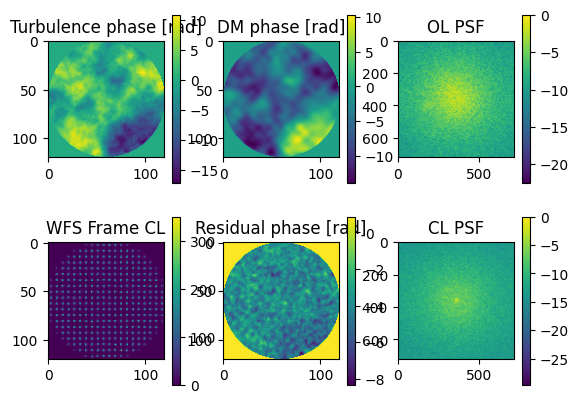

loop 15


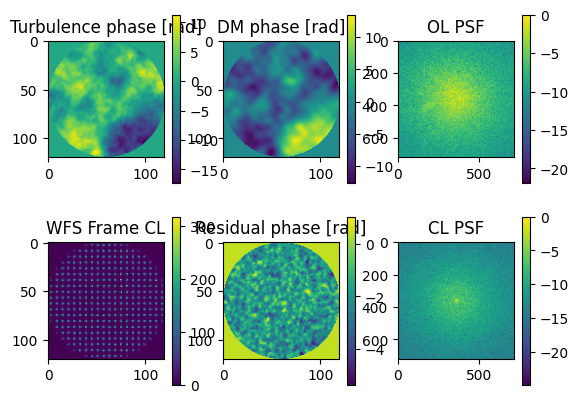

loop 20


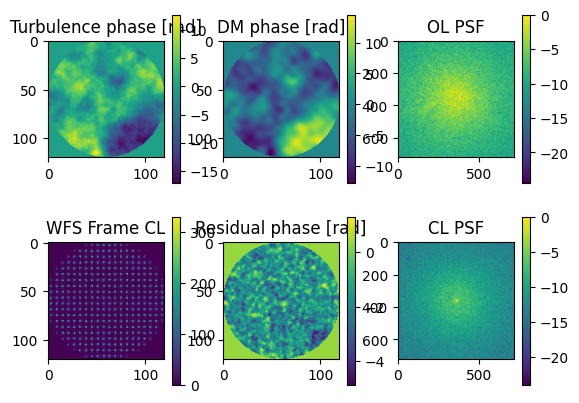

In [15]:
for i in range(20):
    if (i+1) % 5==0:
        print('loop %d' % (i+1))
        plt.subplot(2,3,1)
        im_atm = plt.imshow(im_atm_list[i])
        plt.colorbar(im_atm)
        plt.title('Turbulence phase [rad]')

        plt.subplot(2,3,2)
        im_dm = plt.imshow(im_dm_list[i])
        plt.colorbar(im_dm)
        plt.title('DM phase [rad]')

        plt.subplot(2,3,3)
        im_PSF_OL   = plt.imshow(im_PSF_OL_list[i])
        plt.colorbar(im_PSF_OL)
        plt.title('OL PSF')

        plt.subplot(2,3,4)
        im_wfs_CL   = plt.imshow(im_wfs_CL_list[i])
        plt.colorbar(im_wfs_CL)
        plt.title('WFS Frame CL')

        plt.subplot(2,3,5)
        im_residual = plt.imshow(im_residual_list[i])
        plt.colorbar(im_residual)
        plt.title('Residual phase [rad]')

        plt.subplot(2,3,6)
        im_PSF      = plt.imshow(im_PSF_list[i])
        plt.colorbar(im_PSF)
        plt.title('CL PSF')

        plt.show()
